# TP Jour 1 — Préparer la base pour la modélisation du Jour 2

Vous devez produire une base propre et documentée.  
**Ne construisez pas encore le modèle final.**

Livrables :
1. `data_J1_clean.csv`
2. `dictionnaire_donnees.md`
3. notebook complété et commenté


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


## A. Audit

In [5]:
df = pd.read_csv("../data/data_J1_brut.csv")
# TODO : shape, head, info, describe, NA, doublons, cardinalités
print("Shape :", df.shape)
display(df.head())
df.info()
display(df.describe())

print("Valeurs manquantes :")
print(df.isna().sum())

print("Doublons :", df.duplicated().sum())

print("Valeurs uniques :")
print(df.nunique())

Shape : (423, 10)


,machine_id,ville,type_machine,risque,temperature_C,vibration,pression_bar,age_ans,production_jour,panne
0,M0001,Abomey-Calavi,Compresseur,Faible,NaN,3.00,6.65,13,21256.0,0
1,M0002,Cotonou,Moteur,Moyen,65.0,3.37,6.72,10,28487.0,0
2,M0003,Parakou,Pompe,Faible,77.5,NaN,7.11,15,20511.0,0
3,M0004,Abomey-Calavi,Pompe,Faible,72.5,3.12,NaN,9,31192.0,0
4,M0005,Parakou,Moteur,Moyen,74.1,4.51,6.93,13,9425.0,0


<class 'pandas.DataFrame'>
RangeIndex: 423 entries, 0 to 422
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   machine_id       423 non-null    str    
 1   ville            423 non-null    str    
 2   type_machine     411 non-null    str    
 3   risque           423 non-null    str    
 4   temperature_C    401 non-null    float64
 5   vibration        395 non-null    float64
 6   pression_bar     403 non-null    float64
 7   age_ans          423 non-null    int64  
 8   production_jour  423 non-null    float64
 9   panne            423 non-null    int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 44.0 KB


,temperature_C,vibration,pression_bar,age_ans,production_jour,panne
count,401.000000,395.000000,403.000000,423.000000,423.000000,423.000000
mean,71.091521,3.807247,6.914243,9.033097,25138.876470,0.004728
std,8.658607,2.076071,0.552058,4.768463,9495.106460,0.068680
min,39.000000,-0.230000,5.520000,1.000000,8291.000000,0.000000
25%,66.000000,2.745000,6.495000,5.000000,19832.500000,0.000000
50%,70.600000,3.680000,6.980000,9.000000,24234.000000,0.000000
75%,76.400000,4.535000,7.290000,13.000000,29255.000000,0.000000
max,145.000000,27.474498,8.270000,17.000000,113005.631236,1.000000


Valeurs manquantes :
machine_id          0
ville               0
type_machine       12
risque              0
temperature_C      22
vibration          28
pression_bar       20
age_ans             0
production_jour     0
panne               0
dtype: int64
Doublons : 3
Valeurs uniques :
machine_id         420
ville                4
type_machine         3
risque               3
temperature_C      218
vibration          279
pression_bar       193
age_ans             17
production_jour    417
panne                2
dtype: int64


### Challenge A
Construisez un tableau d'audit avec :
- type
- nombre de NA
- %
- nombre de valeurs uniques
- décision de traitement proposée


In [6]:
# TODO
audit = pd.DataFrame({
    "type": df.dtypes,
    "nb_na": df.isna().sum(),
    "pct_na": (df.isna().mean()*100).round(1),
    "nb_valeurs_uniques": df.nunique()
})
audit["decision"] = ""
audit

,type,nb_na,pct_na,nb_valeurs_uniques,decision
machine_id,str,0,0.0,420,
ville,str,0,0.0,4,
type_machine,str,12,2.8,3,
risque,str,0,0.0,3,
temperature_C,float64,22,5.2,218,
vibration,float64,28,6.6,279,
pression_bar,float64,20,4.7,193,
age_ans,int64,0,0.0,17,
production_jour,float64,0,0.0,417,
panne,int64,0,0.0,2,


## B. Données manquantes — MCAR / MAR / MNAR

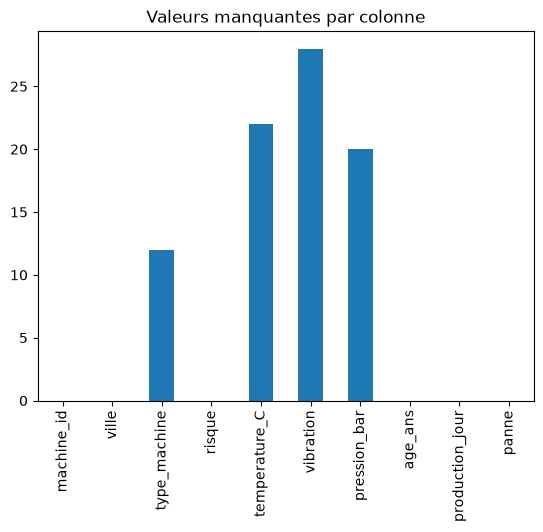

temperature_C
risque
Faible    5.6
Moyen     4.2
Élevé     6.8
Name: temperature_C, dtype: float64
type_machine
Compresseur    6.9
Moteur         4.9
Pompe          4.8
Name: temperature_C, dtype: float64

vibration
risque
Faible    7.6
Moyen     5.4
Élevé     6.8
Name: vibration, dtype: float64
type_machine
Compresseur    5.9
Moteur         9.0
Pompe          5.9
Name: vibration, dtype: float64

pression_bar
risque
Faible    5.1
Moyen     4.2
Élevé     5.1
Name: pression_bar, dtype: float64
type_machine
Compresseur    4.0
Moteur         4.1
Pompe          5.3
Name: pression_bar, dtype: float64



In [7]:
# TODO : visualiser les NA et comparer leur taux selon au moins une variable observée.
# Pour pression_bar, vibration et temperature_C, proposer le mécanisme le plus plausible.
df.isna().sum().plot(kind="bar")
plt.title("Valeurs manquantes par colonne")
plt.show()

for col in ["temperature_C", "vibration", "pression_bar"]:
    print(col)
    print(df.groupby("risque")[col].apply(lambda s: s.isna().mean()*100).round(1))
    print(df.groupby("type_machine")[col].apply(lambda s: s.isna().mean()*100).round(1))
    print()

## C. Nettoyage et imputation

In [8]:
# TODO : traiter doublons et valeurs manquantes.
# Justifier moyenne / médiane / mode / catégorie 'Inconnu' selon les cas.
df = df.drop_duplicates()

df['type_machine'] = df['type_machine'].fillna(df['type_machine'].mode()[0])
for col in ['temperature_C', 'vibration', 'pression_bar']:
    df[col] = df[col].fillna(df[col].median())

print(df.shape)
print(df.isna().sum())

(420, 10)
machine_id         0
ville              0
type_machine       0
risque             0
temperature_C      0
vibration          0
pression_bar       0
age_ans            0
production_jour    0
panne              0
dtype: int64


## D. Valeurs aberrantes

In [9]:
# TODO 1 : boxplot
# TODO 2 : méthode IQR
# TODO 3 : Z-score
# TODO 4 : modified Z-score / MAD
# BONUS : Isolation Forest
cols = ['temperature_C', 'vibration', 'pression_bar']

def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    return (s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)

def z_outliers(s):
    return np.abs(stats.zscore(s)) > 3

def mad_outliers(s):
    med = s.median(); mad = (s - med).abs().median()
    return (0.6745 * (s - med) / mad).abs() > 3.5

results = pd.DataFrame({'machine_id': df['machine_id']})
for col in cols:
    results[f'{col}_IQR'] = iqr_outliers(df[col])
    results[f'{col}_Zscore'] = z_outliers(df[col])
    results[f'{col}_MAD'] = mad_outliers(df[col])

iso = IsolationForest(contamination=0.02, random_state=42)
results['IsolationForest'] = iso.fit_predict(df[cols]) == -1

results['decision_metier'] = ""
results

,machine_id,temperature_C_IQR,temperature_C_Zscore,temperature_C_MAD,vibration_IQR,vibration_Zscore,vibration_MAD,pression_bar_IQR,pression_bar_Zscore,pression_bar_MAD,IsolationForest,decision_metier
0,M0001,False,False,False,False,False,False,False,False,False,False,
1,M0002,False,False,False,False,False,False,False,False,False,False,
2,M0003,False,False,False,False,False,False,False,False,False,False,
3,M0004,False,False,False,False,False,False,False,False,False,False,
4,M0005,False,False,False,False,False,False,False,False,False,False,
...,...,...,...,...,...,...,...,...,...,...,...,...
415,M0416,False,False,False,False,False,False,False,False,False,False,
416,M0417,False,False,False,False,False,False,False,False,False,False,
417,M0418,False,False,False,False,False,False,False,False,False,False,
418,M0419,False,False,False,False,False,False,False,False,False,False,


### Challenge D
Créez un tableau comparatif :
`machine_id | IQR | Z-score | MAD | IsolationForest | décision métier`

Une détection n'est **pas** une suppression automatique.

In [12]:
flag_cols = [c for c in results.columns if c not in ['machine_id','decision_metier']]
suspects = results[results[flag_cols].any(axis=1)]
suspects

,machine_id,temperature_C_IQR,temperature_C_Zscore,temperature_C_MAD,vibration_IQR,vibration_Zscore,vibration_MAD,pression_bar_IQR,pression_bar_Zscore,pression_bar_MAD,IsolationForest,decision_metier
69,M0070,False,False,False,True,False,False,False,False,False,False,
97,M0098,True,True,True,False,False,False,False,False,False,True,
101,M0102,True,True,True,False,False,False,False,False,False,True,
154,M0155,False,False,False,False,False,False,False,False,False,True,
169,M0170,True,False,False,False,False,False,False,False,False,False,
203,M0204,False,False,False,True,True,True,False,False,False,True,
205,M0206,False,False,False,True,True,True,False,False,False,False,
215,M0216,False,False,False,True,False,False,False,False,False,False,
239,M0240,False,False,False,True,False,False,False,False,False,False,
240,M0241,True,False,False,False,False,False,False,False,False,False,


## E. Encodage, normalisation, feature engineering

In [14]:
# TODO :
# - OneHotEncoder pour variables nominales
# - StandardScaler pour numériques si pertinent
# - créer au moins 2 features utiles
# - éviter leakage
df = pd.get_dummies(df, columns=['ville','type_machine'], drop_first=False)

risque_map = {'Faible':0, 'Moyen':1, 'Élevé':2}
df['risque_encoded'] = df['risque'].map(risque_map)

scaler = StandardScaler()
num_cols = ['temperature_C','vibration','pression_bar','age_ans','production_jour']
df[num_cols] = scaler.fit_transform(df[num_cols])

df['temp_par_vibration'] = df['temperature_C'] / (df['vibration'] + 1e-3)
df['machine_ancienne'] = (df['age_ans'] > df['age_ans'].median()).astype(int)

KeyError: "None of [Index(['ville', 'type_machine'], dtype='str')] are in the [columns]"

## F. EDA

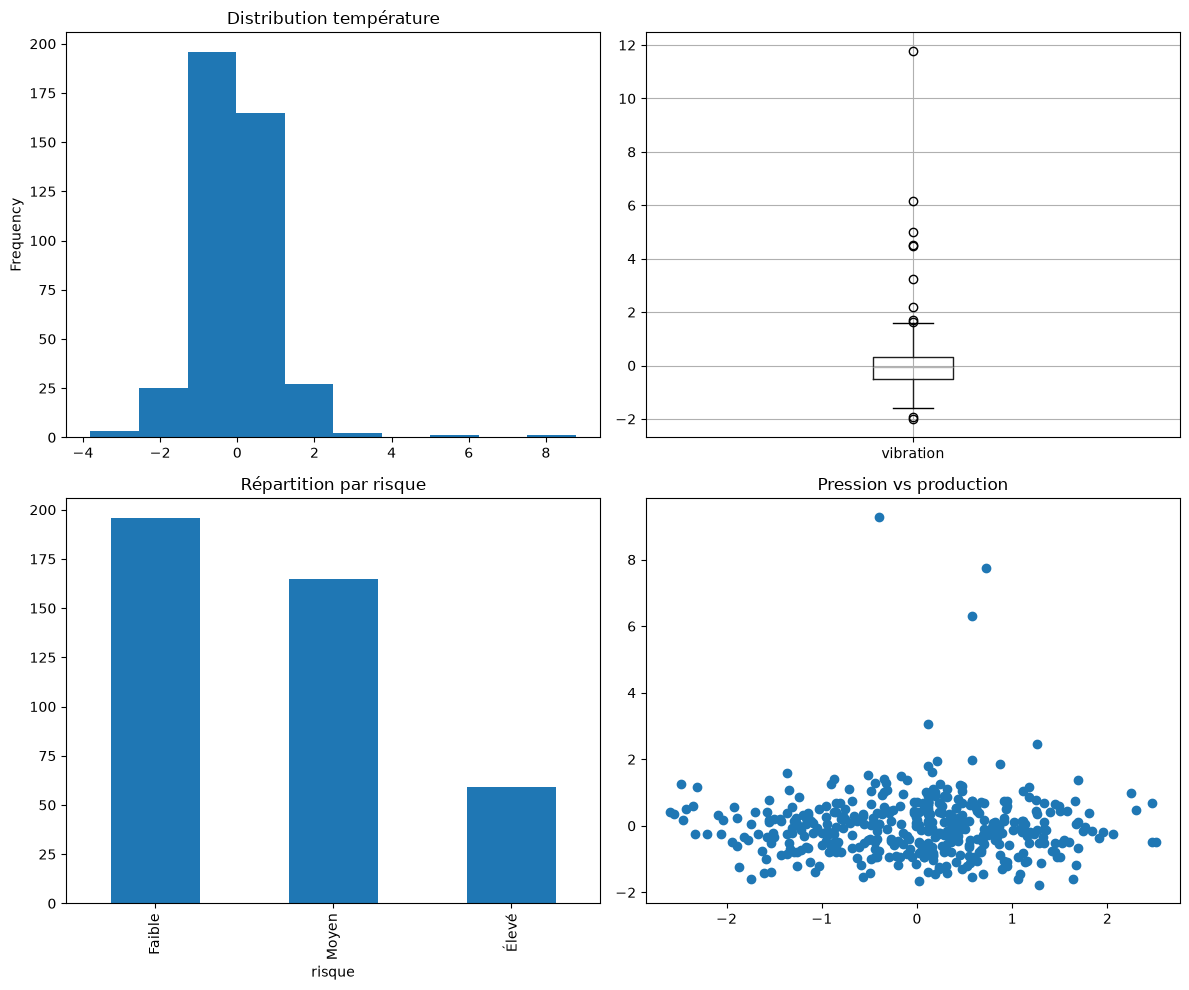

In [15]:
# TODO : produire au moins 4 graphiques :
# 1 histogramme
# 1 boxplot
# 1 barplot
# 1 scatterplot
fig, axes = plt.subplots(2, 2, figsize=(12,10))
df['temperature_C'].plot(kind='hist', ax=axes[0,0], title='Distribution température')
df.boxplot(column='vibration', ax=axes[0,1])
df['risque'].value_counts().plot(kind='bar', ax=axes[1,0], title='Répartition par risque')
axes[1,1].scatter(df['pression_bar'], df['production_jour'])
axes[1,1].set_title('Pression vs production')
plt.tight_layout()
plt.show()

### Conclusions attendues
- 5 constats factuels
- 2 hypothèses à tester au Jour 2
- 3 limites de la base


## G. Export pour le Jour 2

In [16]:
# TODO :
# clean_df.to_csv("../data/data_J1_clean.csv", index=False)
df.to_csv("../data/data_J1_clean.csv", index=False)
print(df.shape)

(420, 18)
